# Data Quality Report : Rister Dataset
**Stageopdracht:** Rovecom Terra | **Auteur:** Sam Berkhout

Dit notebook analyseert de datakwaliteit van de Rister PostgreSQL-database.
Ik structureer de analyses langs vijf ISO 25012 datakwaliteitsdimensies:
1. **Volledigheid** (Completeness)
2. **Consistentie** (Consistency)
3. **Nauwkeurigheid** (Accuracy)
4. **Tijdigheid** (Timeliness)
5. **Bruikbaarheid** voor de ML-modellen

## 0. Setup en imports

Ik importeer alle bibliotheken die ik nodig heb en stel de display-opties in.
`warnings.filterwarnings('ignore')` houdt de output schoon. `sns.set_style('whitegrid')`
en `plt.rcParams['figure.dpi'] = 120` zorgen voor nette grafieken.

In [139]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

## 1. Verbinding met de database

De Rister-data staat in één PostgreSQL-database met drie schema's:
**Orders** (transacties), **Management** (klant- en materiaaldata) en **Shared** (gedeelde lookups).
`TenantId` onderscheidt de bedrijven in deze multi-tenant opzet.

In [140]:
engine = create_engine("postgresql://samberkhout@localhost:5434/rister_prod17")


def get_table(schema, table, columns=None):
    """Lees een tabel uit PostgreSQL en hernoem Id/Name kolommen."""
    cols = ", ".join(f'"{c}"' for c in columns) if columns else "*"
    df = pd.read_sql(f'SELECT {cols} FROM "{schema}"."{table}"', engine)
    df = df.rename(columns={"Id": f"{table.lower()}_id", "Name": f"{table.lower()}name"})
    return df

**Overzicht beschikbare tabellen**

Ik vraag de `information_schema` op om te zien welke tabellen beschikbaar zijn in de drie
schema's: `Orders`, `Management` en `Shared`. Dit geeft een eerste indruk van de
databasestructuur zonder alle data te laden.

In [141]:
schema_overzicht = pd.read_sql(
    """
    SELECT table_schema, table_name
    FROM information_schema.tables
    WHERE table_schema IN ('Orders', 'Management', 'Shared')
    ORDER BY table_schema, table_name
""",
    engine,
)
print(schema_overzicht.to_string(index=False))

table_schema                             table_name
  Management                              Addresses
  Management                          AdminSettings
  Management                              Companies
  Management                       CompanyCountries
  Management                         CompanyLedgers
  Management                 CompanyMailAttachments
  Management               CompanyPaymentConditions
  Management                            CompanyVats
  Management                         EmployeeGroups
  Management                              Equipment
  Management                        EquipmentGroups
  Management             EquipmentToEquipmentGroups
  Management                            FiscalYears
  Management                              GridViews
  Management                             ItemGroups
  Management                         ItemPriceLines
  Management               ItemPriceLinesIndexation
  Management                       ItemToItemGroups
  Management

**Tabellen laden**

Ik laad alle relevante tabellen in een dict via `get_table()`. Die functie hernoemt
automatisch de generieke kolommen `Id` en `Name` naar `{tabel}_id` en `{tabel}name`
om conflicten bij latere merges te voorkomen. De 15 tabellen beslaan de drie schema's.

In [142]:
TABEL_CONFIG = {
    "orders": ("Orders", "Orders"),
    "order_services": ("Orders", "OrderServices"),
    "order_service_line": ("Orders", "OrderServiceLine"),
    "service_line_units": ("Orders", "ServiceLineUnits"),
    "service_line_equip": ("Orders", "ServiceLineEquipment"),
    "time_registration": ("Orders", "TimeRegistration"),
    "relations": ("Management", "Relations"),
    "addresses": ("Management", "Addresses"),
    "services": ("Management", "Services"),
    "service_lines": ("Management", "ServiceLines"),
    "equipment": ("Management", "Equipment"),
    "eq_to_groups": ("Management", "EquipmentToEquipmentGroups"),
    "eq_groups": ("Management", "EquipmentGroups"),
    "planning_groups": ("Management", "PlanningGroups"),
    "units": ("Shared", "Units"),
}

tabellen = {}
for key, (schema, table) in TABEL_CONFIG.items():
    tabellen[key] = get_table(schema, table)
    print(f"{key:25s} {len(tabellen[key]):>8,} rijen")

orders                      34,923 rijen
order_services              38,015 rijen
order_service_line          39,871 rijen
service_line_units          46,427 rijen
service_line_equip          15,023 rijen
time_registration           35,977 rijen
relations                   29,765 rijen
addresses                   73,202 rijen
services                     4,142 rijen
service_lines                4,437 rijen
equipment                    2,614 rijen
eq_to_groups                 2,393 rijen
eq_groups                      398 rijen
planning_groups                425 rijen
units                           29 rijen


**BAG-coördinaten laden**

Ik laad de BAG-CSV met postcodecoördinaten (lat/lon per postcode). De deduplicatie op
`pc` zorgt dat elke postcode maar één keer voorkomt, want anders maakt de merge in stap 8
extra rijen aan.

In [143]:
# BAG coördinaten (postcode → lat/lon)
bag = pd.read_csv("bag_nederland_coords.csv")
bag = bag.drop_duplicates(subset=["pc"])
print(f"BAG coördinaten geladen: {len(bag):,} postcodes")

BAG coördinaten geladen: 473,902 postcodes


**Orders per TenantId**

`TenantId` scheidt de bedrijven in deze gedeelde database. Ik tel hoeveel orders per
tenant er zijn om te zien of de dataverdeling gelijkmatig is of dat één tenant domineert.

In [144]:
if "TenantId" in tabellen["orders"].columns:
    tenant_counts = tabellen["orders"]["TenantId"].value_counts().sort_index()
    print("Orders per TenantId:")
    print(tenant_counts.to_string())
    print(f"\nTotaal tenants: {tenant_counts.shape[0]}")

Orders per TenantId:
TenantId
03210b2d-fc8e-4bd8-a0b5-46d0b98b8ca9    1449
15ed8277-73c5-4aac-aefb-3978e1c7ecc7    2422
1e5b8e61-5940-4e86-9f31-045d8e3fb7ea      31
1fcf3105-00af-4a21-9968-7d15afa4df73     329
22c76114-3ea7-443d-abcd-02c890a9711e       6
2ad2273a-ae82-4fef-8f12-54497c894811     388
2ca4da68-5150-42ad-9cc4-d954289be75e     344
39bf3eb6-b8c2-4832-8f92-d89e9e58ac38     349
3c4a0e35-7a9c-4665-92de-31e48aab20a6     816
40468dd2-328f-4542-b69e-3882aecc8099     446
43dfe60f-65d9-4f69-9646-0d6344233b3d      15
47e405ef-a15f-40bc-be06-a33199799b12      64
4a630add-8af1-4b02-822b-3f22fc29a27d      61
55daaaa9-3a75-47ba-9477-953e8469e766     127
5e8016f5-e1fc-4e15-85c2-a1c8516aee7b      20
62ecb949-2837-4b07-86a5-dd60c6e6348f       8
73d1596b-3ea2-4798-b499-25cb3c0f3898    3406
78eca0d2-4a24-4693-9c34-ddffc9729926     332
7c3a5b2b-7554-4c8e-a548-d12c9ba61d92     734
7d3e7838-599b-48f4-8216-40da21d929cb    1746
863359ba-9560-4814-9fed-d1fe5cebcb39    2261
89c40dca-4cac-4b9d-9636-9

**Relevante kolommen per tabel definiëren**

Ik analyseer alleen de velden die het ML-model daadwerkelijk gebruikt.
`maak_volledigheid_heatmap()` tekent per tabel een heatmap met het vulpercentage per
kolom. Zo zie ik direct welke velden een probleem zijn.

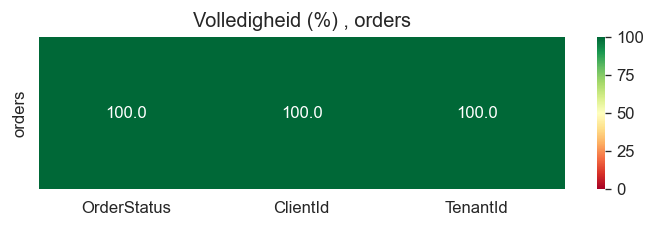

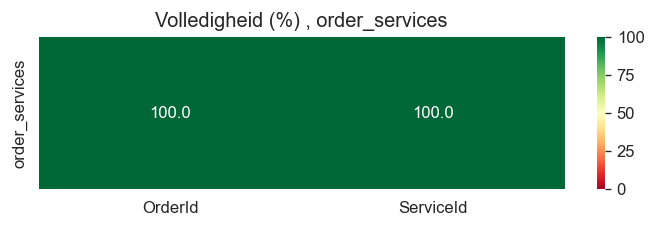

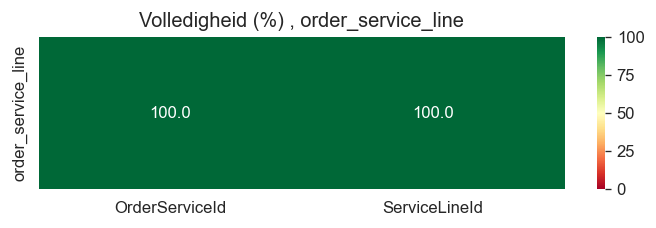

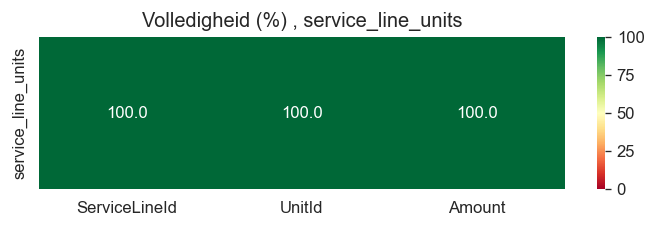

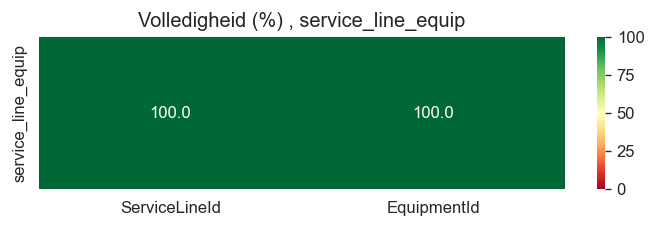

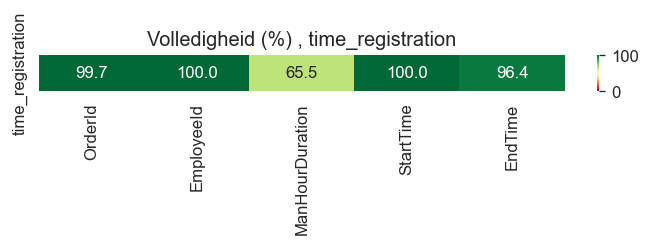

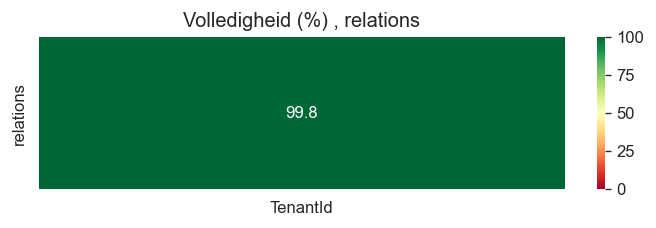

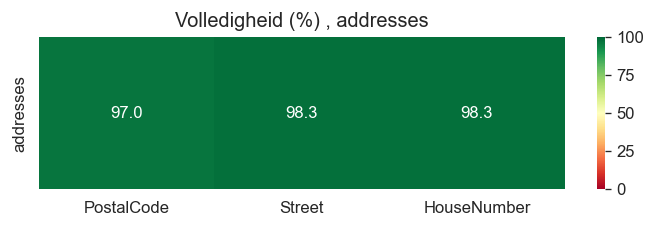

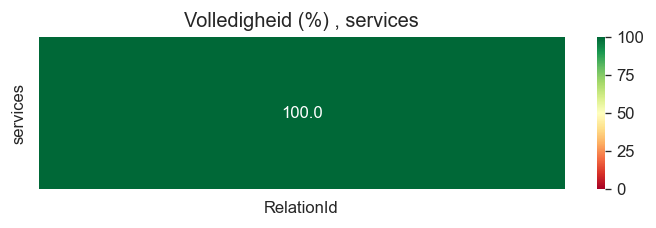

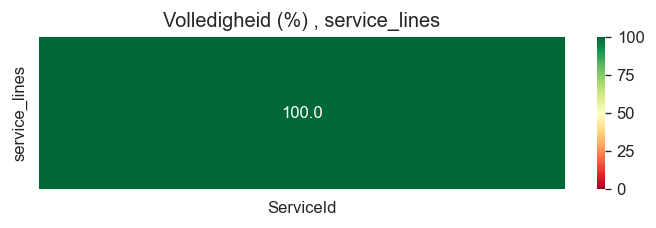

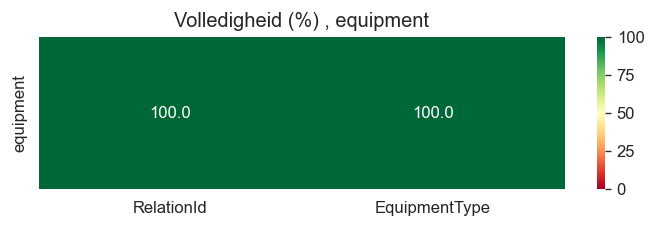

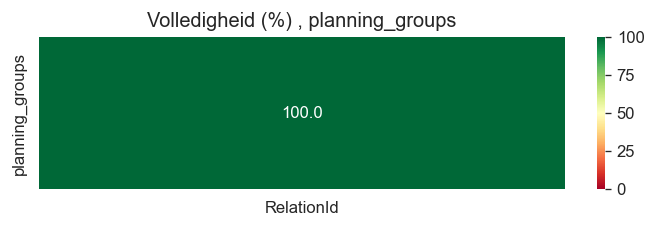

In [145]:
RELEVANTE_KOLOMMEN = {
    "orders": [
        "OrderStatus",
        "ClientId",
        "TenantId",
        "PostalAddressId",
        "PlanningGroupId",
    ],
    "order_services": ["OrderId", "ServiceId"],
    "order_service_line": ["OrderServiceId", "ServiceLineId"],
    "service_line_units": ["ServiceLineId", "UnitId", "Amount"],
    "service_line_equip": ["ServiceLineId", "EquipmentId"],
    "time_registration": ["OrderId", "EmployeeId", "ManHourDuration", "StartTime", "EndTime"],
    "relations": ["ClientId", "TenantId"],
    "addresses": ["PostalCode", "Street", "HouseNumber"],
    "services": ["RelationId"],
    "service_lines": ["ServiceId"],
    "equipment": ["RelationId", "EquipmentType"],
    "planning_groups": ["RelationId"],
    "units": [],
}


def maak_volledigheid_heatmap(tabel_naam, kolommen, toon=True):
    """Teken een heatmap met de vulgraad per kolom."""
    if tabel_naam not in tabellen or not kolommen:
        return None
    df = tabellen[tabel_naam]
    beschikbaar = [c for c in kolommen if c in df.columns]
    if not beschikbaar:
        print(f"{tabel_naam}: geen relevante kolommen gevonden")
        return None
    vulgraad = df[beschikbaar].notna().mean() * 100
    if toon:
        fig, ax = plt.subplots(figsize=(max(6, len(beschikbaar) * 0.8), 2))
        sns.heatmap(
            vulgraad.values.reshape(1, -1),
            annot=True,
            fmt=".1f",
            xticklabels=beschikbaar,
            yticklabels=[tabel_naam],
            cmap="RdYlGn",
            vmin=0,
            vmax=100,
            ax=ax,
        )
        ax.set_title(f"Volledigheid (%) , {tabel_naam}")
        plt.tight_layout()
        plt.show()
    return vulgraad


for tabel, kolommen in RELEVANTE_KOLOMMEN.items():
    maak_volledigheid_heatmap(tabel, kolommen)

## 3. Consistentie (Consistency)

**Onderzoeksvraag:** Zijn de foreign keys intact, zijn datums logisch en zijn waarden consistent over alle tenants?
Ik voer drie soorten checks uit: FK-integriteit, datumlogica en waardeconsistentie.

### 3.1 Foreign key integriteit

Ik controleer 14 FK-relaties: bestaat elke ID in de child-tabel ook in de parent-tabel?
Orphaned records vallen stil weg bij een inner join in de koppelketen, wat het model
traint op onvolledige data zonder dat je het door hebt.

In [146]:
FK_CHECKS = [
    # (child_tabel, child_kolom, parent_tabel, parent_kolom)
    ("order_services", "OrderId", "orders", "orders_id"),
    ("order_service_line", "OrderServiceId", "order_services", "orderservices_id"),
    ("service_line_units", "ServiceLineId", "order_service_line", "orderserviceline_id"),
    ("service_line_units", "UnitId", "units", "units_id"),
    ("service_line_equip", "ServiceLineId", "order_service_line", "orderserviceline_id"),
    ("time_registration", "OrderId", "orders", "orders_id"),
    ("orders", "PlanningGroupId", "planning_groups", "planninggroups_id"),
    ("eq_to_groups", "EquipmentId", "equipment", "equipment_id"),
    ("eq_to_groups", "EquipmentGroupId", "eq_groups", "equipmentgroups_id"),
]

fk_resultaten = []
for child_key, child_col, parent_key, parent_col in FK_CHECKS:
    child_df = tabellen[child_key]
    parent_df = tabellen[parent_key]
    if child_col not in child_df.columns or parent_col not in parent_df.columns:
        fk_resultaten.append(
            {
                "child": child_key,
                "kolom": child_col,
                "parent": parent_key,
                "violations": "kolom niet gevonden",
            }
        )
        continue
    child_ids = child_df[child_col].dropna().unique()
    parent_ids = set(parent_df[parent_col].dropna().unique())
    orphans = [i for i in child_ids if i not in parent_ids]
    fk_resultaten.append(
        {
            "child": child_key,
            "kolom": child_col,
            "parent": parent_key,
            "totaal": len(child_ids),
            "violations": len(orphans),
            "pct": round(len(orphans) / len(child_ids) * 100, 2) if len(child_ids) else 0,
        }
    )

df_fk = pd.DataFrame(fk_resultaten)
print(df_fk.to_string(index=False))
# Filter: alleen rijen met numerieke violations > 0
df_fk_num = df_fk[pd.to_numeric(df_fk["violations"], errors="coerce").notna()]
issues = df_fk_num[df_fk_num["violations"].astype(int) > 0]
niet_gevonden = df_fk[pd.to_numeric(df_fk["violations"], errors="coerce").isna()]
if not niet_gevonden.empty:
    print(f"\n⚠ {len(niet_gevonden)} FK-checks overgeslagen (kolom niet gevonden):")
    for _, r in niet_gevonden.iterrows():
        print(f"  {r['child']}.{r['kolom']} -> {r['parent']}")
if issues.empty:
    print("\n✓ Alle FK-relaties zijn intact")
else:
    print(f"\n⚠ {len(issues)} FK-relaties met violations")

             child            kolom             parent  totaal          violations  pct
    order_services          OrderId             orders 29759.0                   0  0.0
order_service_line   OrderServiceId     order_services 37999.0                   0  0.0
service_line_units    ServiceLineId order_service_line 39488.0                   0  0.0
service_line_units           UnitId              units    19.0                   0  0.0
service_line_equip    ServiceLineId order_service_line 11842.0                   0  0.0
 time_registration          OrderId             orders 23057.0                   0  0.0
            orders  PlanningGroupId    planning_groups     NaN kolom niet gevonden  NaN
      eq_to_groups      EquipmentId          equipment  2358.0                   0  0.0
      eq_to_groups EquipmentGroupId          eq_groups   334.0                   0  0.0

⚠ 1 FK-checks overgeslagen (kolom niet gevonden):
  orders.PlanningGroupId -> planning_groups

✓ Alle FK-relaties zijn 

### 3.2 Datumconsistentie

Startdatum moet altijd voor of gelijk aan einddatum liggen. Omgekeerde datums
duiden op invoerfouten en leveren negatieve duur op, wat de target variable corrupt maakt.

In [147]:
DATUM_CHECKS = [
    ("orders", "StartTime", "EndTime"),
    ("time_registration", "StartTime", "EndTime"),
]

datum_resultaten = []
for tbl_key, start_col, eind_col in DATUM_CHECKS:
    df_tbl = tabellen[tbl_key]
    if start_col not in df_tbl.columns or eind_col not in df_tbl.columns:
        continue
    start = pd.to_datetime(df_tbl[start_col], utc=True, errors="coerce")
    eind = pd.to_datetime(df_tbl[eind_col], utc=True, errors="coerce")
    both = start.notna() & eind.notna()
    totaal = int(both.sum())
    verkeerd = int((start[both] > eind[both]).sum())
    datum_resultaten.append(
        {
            "tabel": tbl_key,
            "check": f"{start_col} ≤ {eind_col}",
            "totaal": totaal,
            "violations": verkeerd,
            "pct": round(verkeerd / totaal * 100, 2) if totaal else 0,
        }
    )

df_datum = pd.DataFrame(datum_resultaten)
print(df_datum.to_string(index=False))
if all(df_datum["violations"] == 0):
    print("\n✓ Alle datumrelaties consistent")

            tabel               check  totaal  violations  pct
time_registration StartTime ≤ EndTime   34683         194 0.56


### 3.3 Waardeconsistentie en duplicaten

Ik check op onrealistische waarden (negatieve uren, uren > 24) en duplicaten.
Negatieve uren of uren boven de 24 zijn fysiek onmogelijk en wijzen op invoerfouten.
Duplicaten in TimeRegistration vertekenen de target variable direct.

In [148]:
check_resultaten = []
tr = tabellen["time_registration"]

# Negatieve ManHourDuration
if "ManHourDuration" in tr.columns:
    negatief = int((tr["ManHourDuration"] < 0).sum())
    check_resultaten.append({"check": "Negatieve ManHourDuration", "violations": negatief})

# ManHourDuration > 24 uur
if "ManHourDuration" in tr.columns:
    boven_24 = int((tr["ManHourDuration"] > 24).sum())
    check_resultaten.append({"check": "ManHourDuration > 24 uur", "violations": boven_24})

# Negatieve Amount in ServiceLineUnits
slu = tabellen["service_line_units"]
if "Amount" in slu.columns:
    neg_amount = int((slu["Amount"] < 0).sum())
    check_resultaten.append(
        {"check": "Negatieve Amount (ServiceLineUnits)", "violations": neg_amount}
    )

# Duplicaten in TimeRegistration
dup_cols = ["OrderId", "EmployeeId", "StartTime"]
dup_cols_present = [c for c in dup_cols if c in tr.columns]
if len(dup_cols_present) == len(dup_cols):
    n_dup = int(tr.duplicated(subset=dup_cols, keep=False).sum())
    check_resultaten.append({"check": "Duplicaat TimeRegistration", "violations": n_dup})

df_checks = pd.DataFrame(check_resultaten)
print(df_checks.to_string(index=False))

                              check  violations
          Negatieve ManHourDuration          15
           ManHourDuration > 24 uur          81
Negatieve Amount (ServiceLineUnits)          40
         Duplicaat TimeRegistration        3582


### 3.4 Cross-tenant consistentie

Hebben gedeelde entiteiten (Units, EquipmentGroups) consistente namen over alle tenants?
Als "Uur" bij tenant A "uur" heet bij tenant B, traint het model op inconsistente
categorie-labels en worden twee dezelfde eenheden als verschillende behandeld.

In [149]:
# Units moeten globaal consistent zijn (Shared schema)
units = tabellen["units"]
print("=== Units (Shared) ===")
print(units[["units_id", "unitsname"]].drop_duplicates().to_string(index=False))
print(f"Unieke units: {units['units_id'].nunique()}")

# ServiceLines per tenant
print("\n=== ServiceLines: unieke namen per tenant ===")
sl = tabellen["service_lines"]
if "RelationId" in sl.columns and "servicelinesname" in sl.columns:
    per_tenant = sl.groupby("RelationId")["servicelinesname"].nunique()
    print(per_tenant.to_string())

# PlanningGroups per tenant
print("\n=== PlanningGroups: unieke namen per tenant ===")
pg = tabellen["planning_groups"]
if "RelationId" in pg.columns and "planninggroupsname" in pg.columns:
    per_tenant = pg.groupby("RelationId")["planninggroupsname"].nunique()
    print(per_tenant.to_string())

=== Units (Shared) ===
 units_id       unitsname
        1             Are
        2            Baal
        3      Centimeter
        4             Dag
        5           Emmer
        6            Gram
        7         Hectare
        8            Jaar
       10        Kilogram
       11       Kilometer
       12           Liter
       13 Vierkante meter
       14   Kubieke meter
       15           Maand
       16           Meter
       17          Pallet
       18             Rit
       19             Roe
       20             Rol
       21            Stuk
       22             Ton
       24          Vracht
       25            Week
       26             Zak
       27       Mililiter
       28       Milimeter
       29         Big bag
       23             Uur
        9            Keer
Unieke units: 29

=== ServiceLines: unieke namen per tenant ===

=== PlanningGroups: unieke namen per tenant ===
RelationId
03210b2d-fc8e-4bd8-a0b5-46d0b98b8ca9    25
15ed8277-73c5-4aac-aefb-3978e1

## 4. Nauwkeurigheid (Accuracy)

**Onderzoeksvraag:** Zijn de waarden realistisch en vrij van onmogelijke uitschieters?
Onnauwkeurige waarden raken het model direct: outliers in de target variable vergroten
de MAE, en foute datums geven verkeerde tijdsfeatures.

### 4.1 Datumbereik

Ik check op NULL-datums bij afgeronde orders, toekomstige datums en zeer oude datums.
Toekomstige datums in historische data zijn per definitie fouten. Zeer oude datums
kunnen legacy-imports zijn die niet representatief zijn voor het huidige werkproces.

In [150]:
# StartTime/EndTime zitten in TimeRegistration, niet in Orders
tr = tabellen["time_registration"].copy()
orders = tabellen["orders"].copy()

# Merge om OrderStatus en TenantId erbij te krijgen
tr = tr.merge(
    orders[["orders_id", "OrderStatus", "TenantId"]],
    left_on="OrderId",
    right_on="orders_id",
    how="left",
)
tr["StartTime"] = pd.to_datetime(tr["StartTime"], utc=True, errors="coerce")
tr["EndTime"] = pd.to_datetime(tr["EndTime"], utc=True, errors="coerce")

afgerond = tr[tr["OrderStatus"].isin([5, 7, 8, 9, 10])]
print(f"Tijdregistraties bij afgeronde orders: {len(afgerond)}")
print(f"  Zonder StartTime: {afgerond['StartTime'].isna().sum()}")
print(f"  Zonder EndTime:   {afgerond['EndTime'].isna().sum()}")

# Datumverdeling
valid_dates = afgerond["StartTime"].dropna()
print(f"\nDatumbereik: {valid_dates.min()} tot {valid_dates.max()}")

# Toekomstige datums
vandaag = pd.Timestamp.now(tz="UTC")
toekomst = int((valid_dates > vandaag).sum())
print(f"Toekomstige datums: {toekomst}")

# Verdeling per jaar per TenantId
if "TenantId" in afgerond.columns:
    afgerond = afgerond.copy()
    afgerond["jaar"] = afgerond["StartTime"].dt.year
    pivot = afgerond.groupby(["TenantId", "jaar"]).size().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(12, 4))
    pivot.T.plot(kind="bar", stacked=True, ax=ax)
    ax.set_title("Tijdregistraties per jaar per TenantId (afgeronde orders)")
    ax.set_xlabel("Jaar")
    ax.set_ylabel("Aantal registraties")
    plt.tight_layout()
    plt.show()

Tijdregistraties bij afgeronde orders: 34568
  Zonder StartTime: 2
  Zonder EndTime:   1200

Datumbereik: 1969-12-31 23:00:00+00:00 tot 2026-07-27 06:00:00+00:00
Toekomstige datums: 14


### 4.2 Taakoverlap, medewerker op twee plekken tegelijk

Als een medewerker twee overlappende tijdregistraties heeft, klopt de planning niet.
Het is ook een data-probleem: de geregistreerde uren tellen dan dubbel, wat
`ManHourDuration` overschat en de target variable corrupt maakt.

In [151]:
tr = tabellen["time_registration"].copy()
tr["StartTime"] = pd.to_datetime(tr["StartTime"], utc=True, errors="coerce")
tr["EndTime"] = pd.to_datetime(tr["EndTime"], utc=True, errors="coerce")
tr = tr.dropna(subset=["StartTime", "EndTime", "EmployeeId"])
tr = tr[tr["EndTime"] > tr["StartTime"]].sort_values(["EmployeeId", "StartTime"])

overlaps = 0
for emp_id, group in tr.groupby("EmployeeId"):
    ends = group["EndTime"].values
    for i, start in enumerate(group["StartTime"].values[1:], 1):
        if start < ends[i - 1]:
            overlaps += 1

print(f"Overlappende tijdregistraties: {overlaps}")
print(f"Medewerkers gecontroleerd: {tr['EmployeeId'].nunique()}")

Overlappende tijdregistraties: 10240
Medewerkers gecontroleerd: 407


### 4.3 Duurverdeling, uitbijters in ManHourDuration

Ik toon de verdeling van gewerkte uren en bepaal de P99-grens.
Die P99-grens gebruik ik als uitbijterdrempel in het DataPrep-notebook. Waarden
boven P99 zijn waarschijnlijk vergeten-uit-te-klokken fouten en worden eruit gefilterd.

ManHourDuration statistieken:
count    20926.000000
mean         5.172788
std          4.073288
min          0.016667
25%          2.000000
50%          4.500000
75%          8.000000
max         82.690000
Name: ManHourDuration, dtype: float64

P99 grens: 16.00 uur
Records boven P99: 199


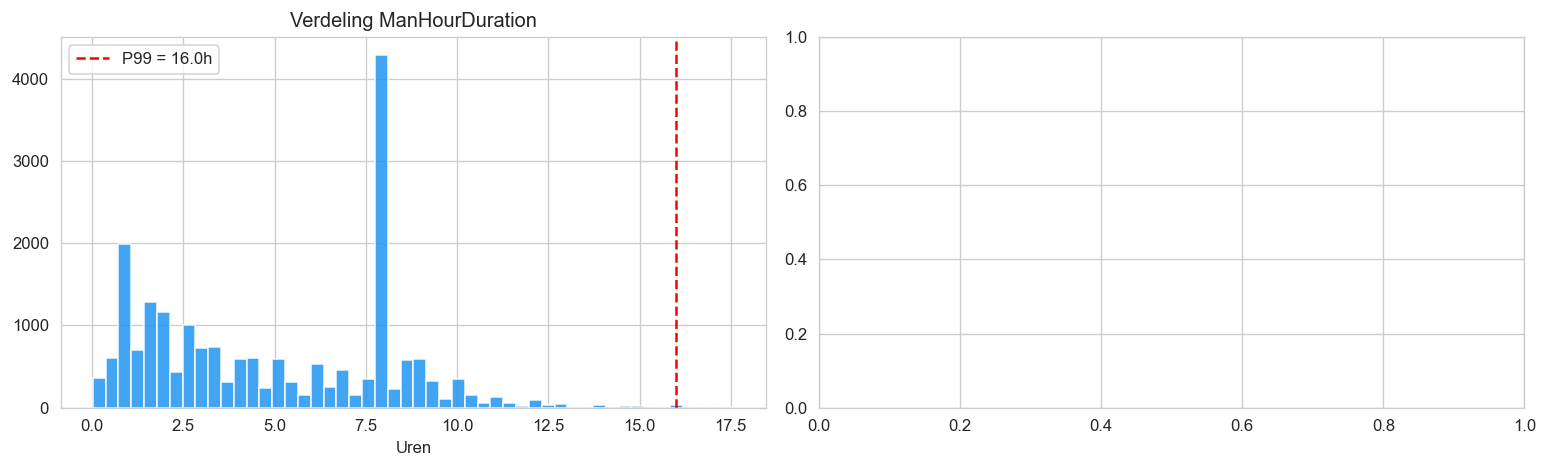

In [152]:
tr = tabellen["time_registration"].copy()
uren = tr["ManHourDuration"].dropna()
uren_pos = uren[uren > 0]

p99 = uren_pos.quantile(0.99)
print("ManHourDuration statistieken:")
print(uren_pos.describe())
print(f"\nP99 grens: {p99:.2f} uur")
print(f"Records boven P99: {(uren_pos > p99).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram , geclipt op 110% van P99
clip = p99 * 1.1
axes[0].hist(uren_pos[uren_pos <= clip], bins=50, color="#2196F3", alpha=0.85, edgecolor="white")
axes[0].axvline(p99, color="red", linestyle="--", label=f"P99 = {p99:.1f}h")
axes[0].set_title("Verdeling ManHourDuration")
axes[0].set_xlabel("Uren")
axes[0].legend()

# Boxplot per TenantId (via orders)
tr_orders = tr.merge(
    tabellen["orders"][["orders_id", "TenantId"]],
    left_on="OrderId",
    right_on="orders_id",
    how="left",
)
tr_orders = tr_orders[tr_orders["ManHourDuration"].between(0.01, p99)]
if "TenantId" in tr_orders.columns:
    tr_orders.boxplot(column="ManHourDuration", by="TenantId", ax=axes[1])
    axes[1].set_title("ManHourDuration per TenantId")
    axes[1].set_xlabel("TenantId")
    axes[1].set_ylabel("Uren")
    plt.suptitle("")

plt.tight_layout()
plt.show()

### 4.4 Equipment-koppeling

Dekkingspercentage: hoeveel order-service-lines hebben equipment toegewezen?
Als het dekkingspercentage laag is, is `EquipmentType` een sparse feature. Dat
beïnvloedt de keuze om het wel of niet mee te nemen in het model.

In [153]:
osl = tabellen["order_service_line"]
sle = tabellen["service_line_equip"]

totaal_osl = osl["orderserviceline_id"].nunique()
met_equip = sle["ServiceLineId"].nunique()
pct = round(met_equip / totaal_osl * 100, 1) if totaal_osl else 0

print(f"Totaal OrderServiceLines:    {totaal_osl:,}")
print(f"Met equipment toegewezen:    {met_equip:,}")
print(f"Dekkingspercentage:          {pct}%")

Totaal OrderServiceLines:    39,871
Met equipment toegewezen:    11,842
Dekkingspercentage:          29.7%


## 5. Tijdigheid (Timeliness)

**Onderzoeksvraag:** Zijn er temporele gaten of verstoringen die de modellering beïnvloeden?
Een model dat traint op data met grote gaten leert seizoenspatronen verkeerd. Gaten
kunnen ook duiden op periodes dat het systeem niet gebruikt werd, wat de dataset vertekent.

### 5.1 Ontbrekende timestamps

PostgreSQL heeft geen Firebird epoch-probleem (1899-12-30). Ik controleer hier op
NULL-timestamps waar die verwacht worden.

In [154]:
TIMESTAMP_CHECKS = {
    "orders": ["StartTime", "EndTime"],
    "time_registration": ["StartTime", "EndTime"],
}

for tbl_key, kolommen in TIMESTAMP_CHECKS.items():
    df_tbl = tabellen[tbl_key]
    print(f"\n=== {tbl_key} ({len(df_tbl):,} rijen) ===")
    for col in kolommen:
        if col not in df_tbl.columns:
            continue
        null_count = int(df_tbl[col].isna().sum())
        pct = round(null_count / len(df_tbl) * 100, 1) if len(df_tbl) else 0
        print(f"  {col}: {null_count:,} NULL ({pct}%)")


=== orders (34,923 rijen) ===

=== time_registration (35,977 rijen) ===
  StartTime: 0 NULL (0.0%)
  EndTime: 1,292 NULL (3.6%)


### 5.2 Registraties per maand per TenantId

Ik toon het patroon van tijdregistraties per maand. Rode verticale lijnen markeren
maanden met minder dan 10% van de mediaan.

In [155]:
tr = tabellen["time_registration"].copy()
tr = tr.merge(
    tabellen["orders"][["orders_id", "TenantId"]],
    left_on="OrderId",
    right_on="orders_id",
    how="left",
)
tr["StartTime"] = pd.to_datetime(tr["StartTime"], utc=True, errors="coerce")
tr = tr[tr["StartTime"].notna()]
tr["jaar_maand"] = tr["StartTime"].dt.to_period("M")

**Registraties per maand per TenantId visualiseren**

Per tenant toon ik het maandelijkse patroon als staafdiagram. Maanden met minder dan
10% van de mediaan worden rood gemarkeerd, dat zijn potentiële gaten of uitval.

In [156]:
if "TenantId" in tr.columns:
    tenants = sorted(tr["TenantId"].dropna().unique())
    fig, axes = plt.subplots(len(tenants), 1, figsize=(14, 3 * len(tenants)), sharex=False)
    if len(tenants) == 1:
        axes = [axes]
    for ax, tenant in zip(axes, tenants):
        sub = tr[tr["TenantId"] == tenant]
        mc = sub.groupby("jaar_maand").size()
        med = mc.median()
        ax.bar(range(len(mc)), mc.values, color="#2980B9", alpha=0.85, edgecolor="white")
        ax.set_title(f"TenantId {tenant}")
        ax.set_ylabel("Registraties")
        ax.text(
            0.98,
            0.95,
            f"Med: {med:.0f} | Min: {mc.min()} | Max: {mc.max()}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8,
        )
        for i, (p, cnt) in enumerate(mc.items()):
            if cnt < med * 0.1:
                ax.axvline(i, color="#E74C3C", lw=1.2, ls="--", alpha=0.7)
        lbl = [str(p) if i % 6 == 0 else "" for i, p in enumerate(mc.index)]
        ax.set_xticks(range(len(mc)))
        ax.set_xticklabels(lbl, rotation=45, ha="right", fontsize=8)
    plt.suptitle("Registraties per maand per TenantId", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

**Temporele gaten detecteren**

`pd.period_range` bouwt de volledige reeks verwachte maanden. Ik vergelijk dat met de
maanden die data bevatten en meld ontbrekende maanden per tenant.

In [157]:
if "TenantId" in tr.columns:
    print("=== Temporele gaten in tijdregistraties ===\n")
    for tenant in sorted(tr["TenantId"].dropna().unique()):
        sub = tr[tr["TenantId"] == tenant]
        mc = sub.groupby("jaar_maand").size()
        alle = pd.period_range(mc.index.min(), mc.index.max(), freq="M")
        mis = alle.difference(mc.index)
        print(
            f"TenantId {tenant}: {mc.index.min()} t/m {mc.index.max()} "
            f"| {len(alle)} verwacht | {len(mis)} ontbrekend"
        )
        if mis:
            print(f"  Ontbrekend: {', '.join(str(m) for m in mis[:10])}")

### 5.3 Seizoenspatronen

Lagere registraties in vakantieperiodes zijn verwacht en geen datakwaliteitsprobleem.
Een plotse daling buiten vakantieperiodes is dat wel: dat wijst op uitval, een migratie
of een periode dat het systeem anders gebruikt werd.

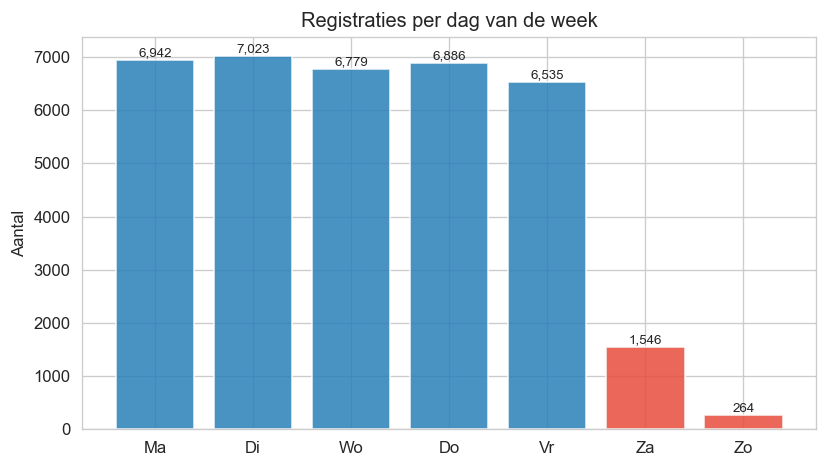

In [158]:
tr_s = tabellen["time_registration"].copy()
tr_s["StartTime"] = pd.to_datetime(tr_s["StartTime"], utc=True, errors="coerce")
tr_s = tr_s[tr_s["StartTime"].notna()]
tr_s["dag_week"] = tr_s["StartTime"].dt.dayofweek
tr_s["maand_nr"] = tr_s["StartTime"].dt.month

dag_cnt = tr_s["dag_week"].value_counts().sort_index()
kleuren_dag = ["#2980B9"] * 5 + ["#E74C3C"] * 2
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dag_cnt.index, dag_cnt.values, color=kleuren_dag, alpha=0.85, edgecolor="white")
ax.set_xticks(range(7))
ax.set_xticklabels(["Ma", "Di", "Wo", "Do", "Vr", "Za", "Zo"])
for i, v in enumerate(dag_cnt.values):
    ax.text(i, v + dag_cnt.max() * 0.01, f"{v:,}", ha="center", fontsize=8)
ax.set(title="Registraties per dag van de week", ylabel="Aantal")
plt.tight_layout()
plt.show()

**Registraties per kalendermaand, seizoenspatroon**

Lagere aantallen in juli-augustus en december zijn verwacht (vakantie) en geen
datakwaliteitsprobleem. Ik markeer die periodes met `axvspan`.

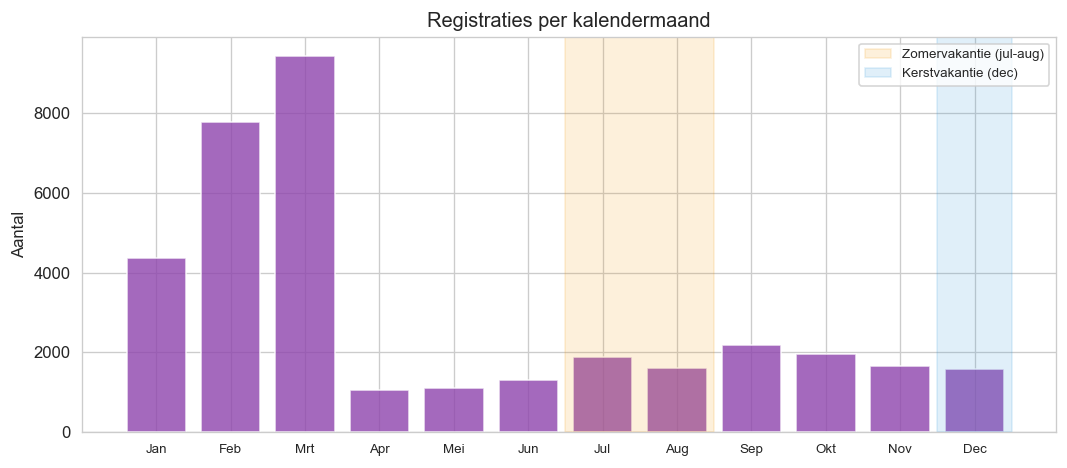

In [159]:
maand_cnt = tr_s["maand_nr"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(maand_cnt.index, maand_cnt.values, color="#8E44AD", alpha=0.8, edgecolor="white")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    ["Jan", "Feb", "Mrt", "Apr", "Mei", "Jun", "Jul", "Aug", "Sep", "Okt", "Nov", "Dec"], fontsize=8
)
ax.axvspan(6.5, 8.5, color="#F39C12", alpha=0.15, label="Zomervakantie (jul-aug)")
ax.axvspan(11.5, 12.5, color="#3498DB", alpha=0.15, label="Kerstvakantie (dec)")
ax.set(title="Registraties per kalendermaand", ylabel="Aantal")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Bruikbaarheid voor de ML-modellen

**Onderzoeksvraag:** Welke tabellen en velden leveren bruikbare features op
voor Model 1 (tijdsvoorspelling) en Model 2 (resource-matching)?

Vijf deelanalyses:
1. **OrderStatus-verdeling**: welke statussen zijn bruikbaar?
2. **Target variable**: verdeling van hoeveelheid_uur
3. **Koppelketen**: hoeveel records overleven de volledige join-chain?
4. **Feature beschikbaarheid**: vulgraad per feature
5. **Medewerker-activiteit**: dekking voor resource-matching

### 6.1 OrderStatus-verdeling

Statussen 5, 7, 8, 9, 10 zijn bruikbaar (afgeronde/gefactureerde orders).
Lagere statussen zijn nog in uitvoering en hebben geen definitieve tijdregistratie,
dus die gebruik ik niet als traindata.

OrderStatus
0         1
1        27
2       451
4       469
5      1908
7       789
8      2536
9     23623
10     5070
11       49

Bruikbaar: 33,926 / 34,923 (97.1%)


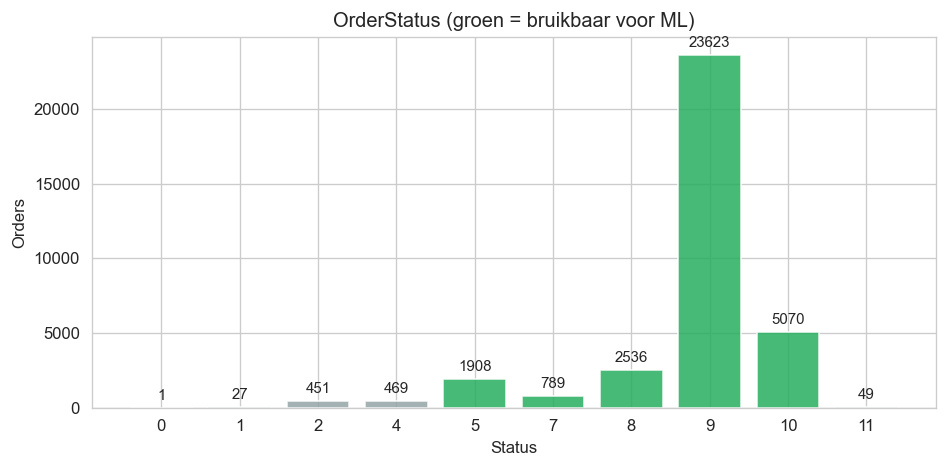

In [160]:
orders = tabellen["orders"].copy()
status_cnt = orders["OrderStatus"].value_counts().sort_index()
bruikbaar = [5, 7, 8, 9, 10]
n_bruikbaar = int(orders["OrderStatus"].isin(bruikbaar).sum())
n_overig = len(orders) - n_bruikbaar
print(status_cnt.to_string())
print(f"\nBruikbaar: {n_bruikbaar:,} / {len(orders):,} ({n_bruikbaar / len(orders) * 100:.1f}%)")

colors = ["#27AE60" if s in bruikbaar else "#95A5A6" for s in status_cnt.index]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(status_cnt.index.astype(str), status_cnt.values, color=colors, alpha=0.85)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set(title="OrderStatus (groen = bruikbaar voor ML)", xlabel="Status", ylabel="Orders")
plt.tight_layout()
plt.show()

**Proportie bruikbare orders als taartdiagram**

De staafdiagram hierboven toont de aantallen per status. Dit taartdiagram maakt de
totaalverhouding direct leesbaar.

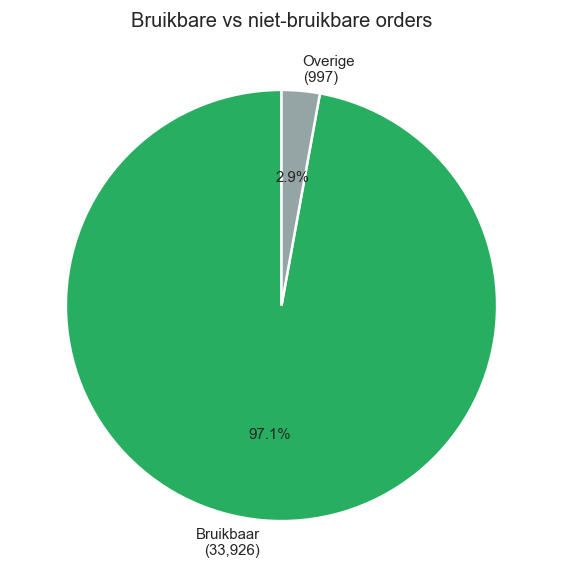

In [161]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(
    [n_bruikbaar, n_overig],
    labels=[f"Bruikbaar\n({n_bruikbaar:,})", f"Overige\n({n_overig:,})"],
    colors=["#27AE60", "#95A5A6"],
    startangle=90,
    autopct="%1.1f%%",
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 9},
)
ax.set_title("Bruikbare vs niet-bruikbare orders")
plt.tight_layout()
plt.show()

### 6.2 Verdeling target variable (hoeveelheid_uur)

De target variable is `Amount` waar de unit "Uur" is, wat overeenkomt met
`REAL_WORKED_TIME` in WerkExpert. Ik kijk naar de verdeling, mediaan en P99-grens
om te beoordelen of de data geschikt is voor regressie.

In [162]:
slu = tabellen["service_line_units"].copy()
slu = slu.merge(tabellen["units"], left_on="UnitId", right_on="units_id", how="left")
uur_pos = slu[slu["unitsname"] == "Uur"]["Amount"].dropna().pipe(lambda s: s[s > 0])
p25, p50, p75, p99 = uur_pos.quantile([0.25, 0.50, 0.75, 0.99])
print(uur_pos.describe())
print(f"\nP99 (uitbijtergrens): {p99:.2f} uur")

count    24541.000000
mean         4.687211
std          3.258214
min          0.080000
25%          1.750000
50%          4.000000
75%          8.000000
max         23.980000
Name: Amount, dtype: float64

P99 (uitbijtergrens): 12.25 uur


**Verdeling van de target variable als histogram**

Ik clip de x-as op 105% van P99 zodat uitbijters de schaal niet vervormen. De mediaan,
8-uursgrens en P99 zijn als referentielijnen ingetekend.

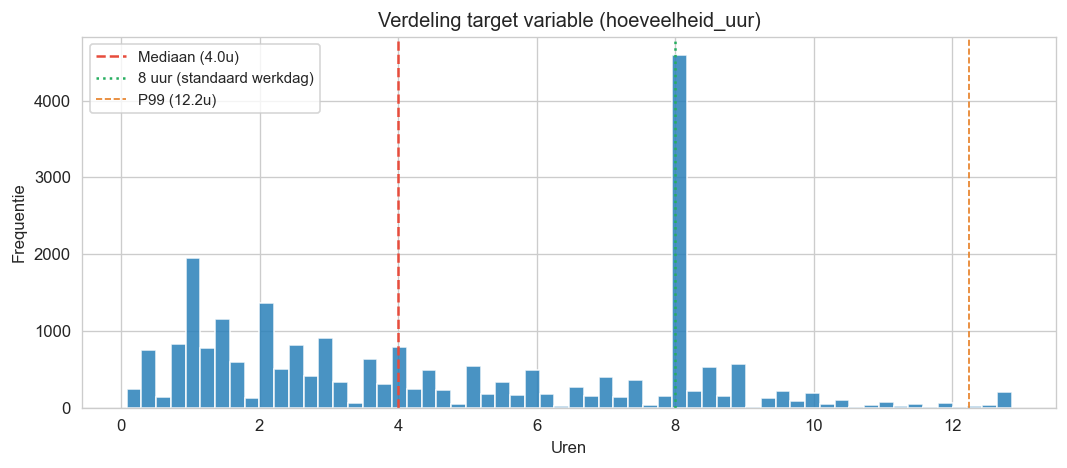

In [163]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(uur_pos.clip(upper=p99 * 1.05), bins=60, color="#2980B9", alpha=0.85, edgecolor="white")
ax.axvline(p50, color="#E74C3C", lw=1.5, ls="--", label=f"Mediaan ({p50:.1f}u)")
ax.axvline(8, color="#27AE60", lw=1.5, ls=":", label="8 uur (standaard werkdag)")
ax.axvline(p99, color="#E67E22", lw=1, ls="--", label=f"P99 ({p99:.1f}u)")
ax.set(xlabel="Uren", ylabel="Frequentie", title="Verdeling target variable (hoeveelheid_uur)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Target variable per TenantId als boxplot**

Per tenant toon ik de spreiding van de geregistreerde uren. Zo zie ik of tenants
structureel andere werktijden hebben, wat relevant is voor het model.

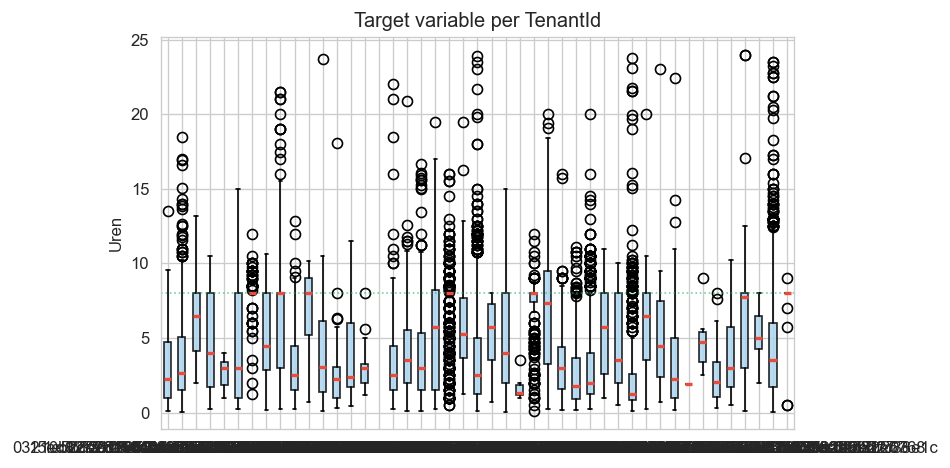

In [164]:
# Boxplot per TenantId , verbind via OrderServiceLine → OrderServices → Orders
osl = tabellen["order_service_line"][["orderserviceline_id", "OrderServiceId"]]
osvc = tabellen["order_services"][["orderservices_id", "OrderId"]]
ord_ = tabellen["orders"][["orders_id", "TenantId"]]
slu_t = (
    slu[slu["unitsname"] == "Uur"]
    .merge(osl, left_on="ServiceLineId", right_on="orderserviceline_id", how="left")
    .merge(osvc, left_on="OrderServiceId", right_on="orderservices_id", how="left")
    .merge(ord_, left_on="OrderId", right_on="orders_id", how="left")
)
tids = sorted(slu_t["TenantId"].dropna().unique())
data = [
    slu_t[slu_t["TenantId"] == t]["Amount"].dropna().pipe(lambda s: s[s > 0]).values for t in tids
]
fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(
    data,
    labels=[str(t) for t in tids],
    patch_artist=True,
    medianprops={"color": "#E74C3C", "lw": 2},
)
for p in bp["boxes"]:
    p.set_facecolor("#AED6F1")
    p.set_alpha(0.85)
ax.axhline(8, color="#27AE60", lw=1, ls=":", alpha=0.6)
ax.set(title="Target variable per TenantId", ylabel="Uren")
plt.tight_layout()
plt.show()

### 6.3 Koppelketen volledigheid

Ik test stap voor stap hoeveel records de volledige koppelketen overleven.
Een grote drop bij een inner join betekent dat veel orders geen koppeling hebben,
wat het trainingsvolume verkleint. Left joins verliezen geen records maar kunnen
sparse features opleveren.

### Stap 1: Orders filteren op bruikbare status

Ik filter op statuscodes 5, 7, 8, 9 en 10, dit zijn afgeronde of gefactureerde orders.
Dit is de startpopulatie van de koppelketen. Alle verliespercentages verder in de funnel
zijn relatief aan dit getal.

In [165]:
# Stap 1: Orders met bruikbare status
orders = tabellen["orders"].copy()
stap1 = orders[orders["OrderStatus"].isin([5, 7, 8, 9, 10])]
n_stap1 = len(stap1)

### Stap 2: Koppelen aan OrderServices (inner join)

Elke order kan meerdere services bevatten. Inner join op `orders_id` naar `OrderId`.
Orders zonder service-record vallen hier af.

In [166]:
# Stap 2: + OrderServices
os_df = tabellen["order_services"]
stap2 = stap1.merge(os_df, left_on="orders_id", right_on="OrderId", how="inner")
n_stap2 = len(stap2)

### Stap 3: Koppelen aan OrderServiceLine (inner join)

Een service kan meerdere service-lines hebben, één per activiteitentype. Inner join op
`orderservices_id` naar `OrderServiceId`. Dit bepaalt de granulariteit: één rij per
order-service-line combinatie.

In [167]:
# Stap 3: + OrderServiceLine
osl = tabellen["order_service_line"]
stap3 = stap2.merge(osl, left_on="orderservices_id", right_on="OrderServiceId", how="inner")
n_stap3 = len(stap3)

### Stap 4: Koppelen aan ServiceLineUnits, filteren op eenheid "Uur" (inner join)

`ServiceLineUnits` bevat de hoeveelheid per eenheid (bijv. "Uur", "Stuks"). Ik merge
eerst met `Units` voor de eenheidsnaam, dan filter ik op `unitsname == 'Uur'`. Alleen
uur-registraties zijn relevant voor de tijdsvoorspelling.

In [168]:
# Stap 4: + ServiceLineUnits (filter op Uur)
slu = tabellen["service_line_units"].merge(
    tabellen["units"], left_on="UnitId", right_on="units_id", how="left"
)
slu_uur = slu[slu["unitsname"] == "Uur"]
stap4 = stap3.merge(slu_uur, left_on="orderserviceline_id", right_on="ServiceLineId", how="inner")
n_stap4 = len(stap4)

### Stap 5: Koppelen aan ServiceLineEquipment (left join)

Niet elke service-line heeft equipment. Left join zodat rijen zonder equipment niet
wegvallen. `n_stap5` telt hoeveel rijen wel een `EquipmentId` hebben.

In [169]:
# Stap 5: + ServiceLineEquipment (left: niet elke taak heeft equipment)
sle = tabellen["service_line_equip"]
stap5 = stap4.merge(sle, left_on="orderserviceline_id", right_on="ServiceLineId", how="left")
n_stap5 = int(stap5["EquipmentId"].notna().sum())

### Stap 6: Koppelen aan TimeRegistration (inner join)

Tijdregistraties koppel ik op `[OrderId, EmployeeId]`. Alleen rijen met een daadwerkelijke
tijdregistratie overleven. Dit is de kern van de dataset: medewerker, taak en geregistreerde uren.
Ik drop `TenantId`, `StartTime` en `EndTime` uit `time_registration` voor de merge, anders
krijg ik suffix-conflicten met dezelfde kolommen uit `orders`.

In [170]:
# Stap 6: + TimeRegistration (via OrderId + EmployeeId)
tr = tabellen["time_registration"].drop(
    columns=["TenantId", "StartTime", "EndTime"], errors="ignore"
)
stap6 = stap5.merge(tr, on=["OrderId", "EmployeeId"], how="inner")
n_stap6 = len(stap6)

### Stap 7: Koppelen aan Relations (left join)

`Relations` bevat klantgegevens per tenant. Ik drop eerst `TenantId` uit de relatie-tabel,
die kolom conflicteert met `TenantId` uit `orders`. Left join: klanten zonder
relatie-record blijven in de dataset.

In [171]:
# Stap 7: + Relations (drop TenantId zoals in DataPrep)
rel = tabellen["relations"].drop(columns="TenantId", errors="ignore")
stap7 = stap6.merge(rel, left_on="TenantId", right_on="relations_id", how="left")
n_stap7_met_rel = int(stap7["relations_id"].notna().sum())

### Stap 8: Koppelen aan Addresses en BAG-coördinaten (left join)

Ik normaliseer de postcode (uppercase, spaties weg) zodat de BAG-koppeling klopt. De
BAG-CSV geeft lat/lon per postcode. Left join: adressen zonder postcode of BAG-match
blijven behouden.

In [172]:
# Stap 8: + Addresses + BAG coördinaten
addr = tabellen["addresses"].copy()
addr["PostalCode"] = addr["PostalCode"].str.upper().str.replace(" ", "", regex=False)
addr = addr.merge(bag, left_on="PostalCode", right_on="pc", how="left")
stap8 = stap7.merge(addr, left_on="PostalAddressId", right_on="addresses_id", how="left")
n_stap8_met_pc = int(stap8["PostalCode"].notna().sum())
n_stap8_met_loc = int(stap8["lat"].notna().sum())

### Stap 9: Koppelen aan Services (left join)

`Services` beschrijft welke diensten een klant afneemt. Koppeling op
`[TenantId, ServiceId]` naar `[RelationId, services_id]`. Left join: niet elke
order-service-line heeft een actieve service-beschrijving.

In [173]:
# Stap 9: + Services
svc = tabellen["services"]
stap9 = stap8.merge(
    svc, left_on=["TenantId", "ServiceId"], right_on=["RelationId", "services_id"], how="left"
)
n_stap9_met_svc = int(stap9["services_id"].notna().sum())

### Stap 10: Koppelen aan ServiceLines (left join)

`ServiceLines` geeft de naam van de activiteit (bijv. "Glasreiniging"). Ik koppel op
`ServiceLineId_x`. Dat `_x`-suffix ontstaat doordat zowel `OrderServiceLine` als
`ServiceLineUnits` een kolom `ServiceLineId` hebben die pandas bij een eerdere merge
heeft gedistingueerd.

In [174]:
# Stap 10: + ServiceLines
sl = tabellen["service_lines"]
stap10 = stap9.merge(sl, left_on="ServiceLineId_x", right_on="servicelines_id", how="left")
n_stap10_met_sl = int(stap10["servicelines_id"].notna().sum())

### Stap 11: Koppelen aan Equipment en groepen (left join)

Equipment is gekoppeld via twee tussenstappen: `EquipmentToEquipmentGroups` en
`EquipmentGroups`. Ik drop `RelationId` uit `EquipmentGroups` om conflicten te vermijden.
Left join: niet elke taak heeft equipment.

In [175]:
# Stap 11: + Equipment + EquipmentToEquipmentGroups + EquipmentGroups
eq = tabellen["equipment"].copy()
eq2g = tabellen["eq_to_groups"]
eqg = tabellen["eq_groups"].drop(columns=["RelationId"], errors="ignore")
eq = eq.merge(eq2g, left_on="equipment_id", right_on="EquipmentId", how="left")
eq = eq.merge(eqg, left_on="EquipmentGroupId", right_on="equipmentgroups_id", how="left")
stap11 = stap10.merge(eq, left_on="EquipmentId", right_on="equipment_id", how="left")
n_stap11_met_eq = int(stap11["equipment_id"].notna().sum())

### Stap 12: Koppelen aan PlanningGroups (left join)

PlanningGroups geven aan in welke planningsgroep een order valt. Dit is de laatste stap
van de koppelketen. Na deze merge is `stap12` de volledige dataset zoals het
DataPrep-notebook die ook opbouwt.

In [176]:
# Stap 12: + PlanningGroups
pg = tabellen["planning_groups"]
stap12 = stap11.merge(pg, left_on="PlanningGroupId", right_on="planninggroups_id", how="left")
n_stap12_met_pg = int(stap12["planninggroups_id"].notna().sum())

**Koppelketen funnel visualiseren**

Ik toon het aantal records per stap als horizontaal staafdiagram. De kleur geeft het
type join aan: groen = inner join met verlies <1%, oranje = 1-5%, rood = >5%, blauw =
left join (dekking, geen recordverlies).

In [ ]:
counts_f = [
    n_stap1,
    n_stap2,
    n_stap3,
    n_stap4,
    n_stap5,
    n_stap6,
    n_stap7_met_rel,
    n_stap8_met_pc,
    n_stap8_met_loc,
    n_stap9_met_svc,
    n_stap10_met_sl,
    n_stap11_met_eq,
    n_stap12_met_pg,
]
labels_f = [
    "Orders (status 5/7/8/9/10)",
    "+ OrderServices",
    "+ OrderServiceLine",
    "+ ServiceLineUnits (Uur)",
    "  met Equipment (left)",
    "+ TimeRegistration",
    "  met Relations (left)",
    "  met PostalCode (left)",
    "  met lat/lon BAG (left)",
    "  met Services (left)",
    "  met ServiceLines (left)",
    "  met Equipment details (left)",
    "  met PlanningGroups (left)",
]
joins_f = ["inner"] * 4 + ["left", "inner"] + ["left"] * 7


def stap_kleur(i):
    if i == 0 or joins_f[i] == "left":
        return "#27AE60" if i == 0 else "#2980B9"
    v = (counts_f[i - 1] - counts_f[i]) / n_stap1 * 100
    return "#27AE60" if v < 1 else "#F39C12" if v < 5 else "#E74C3C"


fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(
    range(len(labels_f)),
    counts_f,
    color=[stap_kleur(i) for i in range(len(labels_f))],
    alpha=0.88,
    edgecolor="white",
    height=0.6,
)
ax.set_yticks(range(len(labels_f)))
ax.set_yticklabels(labels_f, fontsize=9)
ax.invert_yaxis()
pcts = [c / n_stap1 * 100 for c in counts_f]
for i, (n, p) in enumerate(zip(counts_f, pcts)):
    ax.text(n + n_stap1 * 0.004, i, f"{n:,} ({p:.1f}%)", va="center", fontsize=8)
legenda = [
    mpatches.Patch(color=c, label=label)
    for c, label in [
        ("#27AE60", "Inner, verlies <1%"),
        ("#F39C12", "Inner, verlies 1-5%"),
        ("#E74C3C", "Inner, verlies >5%"),
        ("#2980B9", "Left join (dekking)"),
    ]
]
ax.legend(handles=legenda, fontsize=8, loc="lower right")
ax.set(xlabel="Aantal records", title="Koppelketen volledigheid (DataPrep-volgorde)")
plt.tight_layout()
plt.show()

### 6.4 Feature beschikbaarheid per model

Overzicht van alle features die het DataPrep-notebook (`notebooks/2.DataPrep/rister.ipynb`) genereert.
De koppelketen hierboven volgt exact dezelfde merge-volgorde als het DataPrep-notebook.

In [178]:
FEATURES = [
    # (feature, brontabel, model1, model2)
    ("EmployeeId", "TimeRegistration", True, True),
    ("ServiceLineId_x", "OrderServiceLine", True, True),
    ("PlanningGroupId", "Orders", True, True),
    ("EquipmentGroupId", "Equipment", True, True),
    ("ClientId", "Orders", True, True),
    ("TenantId_x", "Orders", True, True),
    ("servicelinesname", "ServiceLines", True, True),
    ("equipmentname", "Equipment", True, True),
    ("EquipmentType_y", "Equipment", True, True),
    ("EquipmentGroupTypes", "EquipmentGroups", True, True),
    ("planninggroupsname", "PlanningGroups", False, True),
    ("PostalCode", "Addresses", True, False),
    ("lat", "BAG CSV", True, False),
    ("lon", "BAG CSV", True, False),
    ("ManHourDuration", "TimeRegistration", True, False),
    ("Amount", "ServiceLineUnits", True, False),
]
df_feat = pd.DataFrame(FEATURES, columns=["feature", "tabel", "model1", "model2"])
df_feat["vulgraad"] = df_feat["feature"].apply(
    lambda f: round(stap12[f].notna().mean() * 100, 1) if f in stap12.columns else 0
)
df_feat = df_feat.sort_values("vulgraad", ascending=True)
print(df_feat[["feature", "tabel", "vulgraad", "model1", "model2"]].to_string(index=False))

            feature            tabel  vulgraad  model1  model2
         TenantId_x           Orders       0.0    True    True
   EquipmentGroupId        Equipment      41.0    True    True
EquipmentGroupTypes  EquipmentGroups      41.0    True    True
      equipmentname        Equipment      43.4    True    True
    EquipmentType_y        Equipment      43.4    True    True
    ManHourDuration TimeRegistration      64.8    True   False
   servicelinesname     ServiceLines      98.5    True    True
    PlanningGroupId           Orders      99.4    True    True
 planninggroupsname   PlanningGroups      99.4   False    True
                lat          BAG CSV      99.5    True   False
                lon          BAG CSV      99.5    True   False
         PostalCode        Addresses      99.6    True   False
         EmployeeId TimeRegistration     100.0    True    True
    ServiceLineId_x OrderServiceLine     100.0    True    True
           ClientId           Orders     100.0    True 

**Vulgraad per feature visualiseren**

Groen (>=95%) = voldoende. Oranje (80-95%) = controleren. Rood (<80%) = problematisch.
De 95%- en 80%-grenzen zijn als referentielijnen ingetekend.

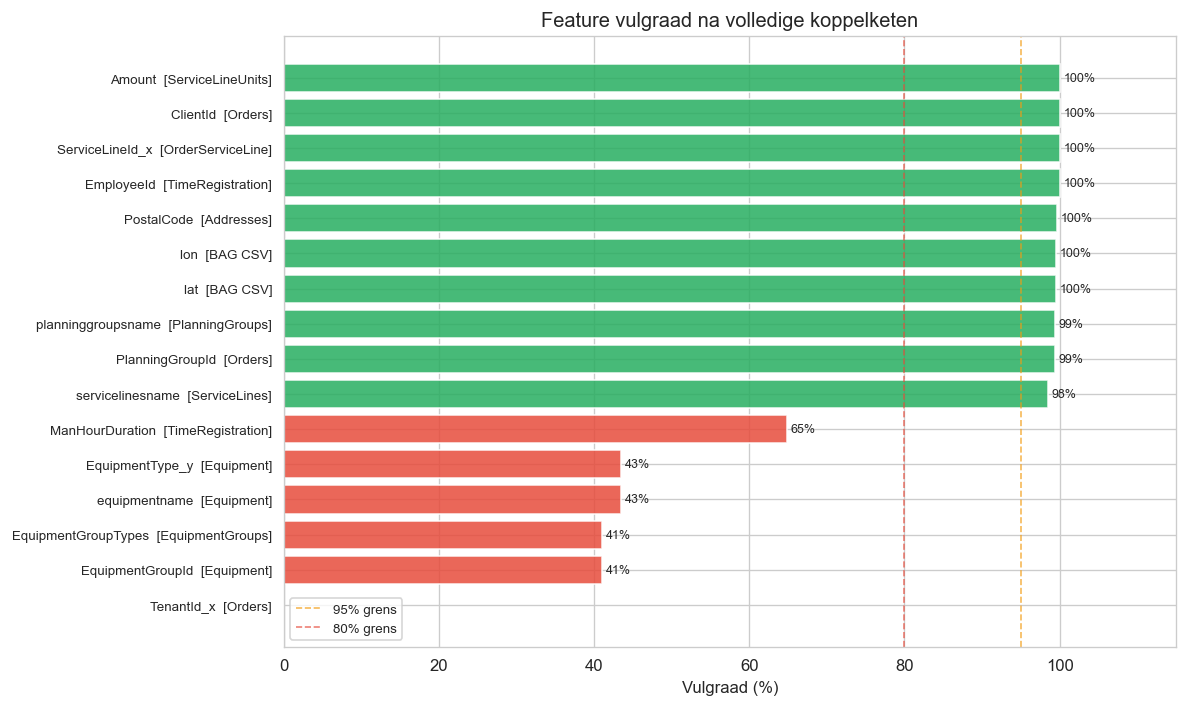

In [179]:
kleuren_vul = [
    "#E74C3C" if v < 80 else "#F39C12" if v < 95 else "#27AE60" for v in df_feat["vulgraad"]
]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(df_feat)), df_feat["vulgraad"], color=kleuren_vul, alpha=0.85, edgecolor="white")
ax.set_yticks(range(len(df_feat)))
ax.set_yticklabels([f"{r.feature}  [{r.tabel}]" for _, r in df_feat.iterrows()], fontsize=8)
ax.set_xlim(0, 115)
ax.axvline(95, color="#F39C12", lw=1, ls="--", alpha=0.7, label="95% grens")
ax.axvline(80, color="#E74C3C", lw=1, ls="--", alpha=0.7, label="80% grens")
ax.set(xlabel="Vulgraad (%)", title="Feature vulgraad na volledige koppelketen")
ax.legend(fontsize=8)
for i, v in enumerate(df_feat["vulgraad"]):
    if v > 0:
        ax.text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=7.5)
plt.tight_layout()
plt.show()

**Relevantie per feature per model**

Een vinkje geeft aan dat een feature relevant is voor dat model. Model 1 voorspelt de
tijdsduur (target: `Amount` in uren), Model 2 matcht medewerkers aan activiteiten.

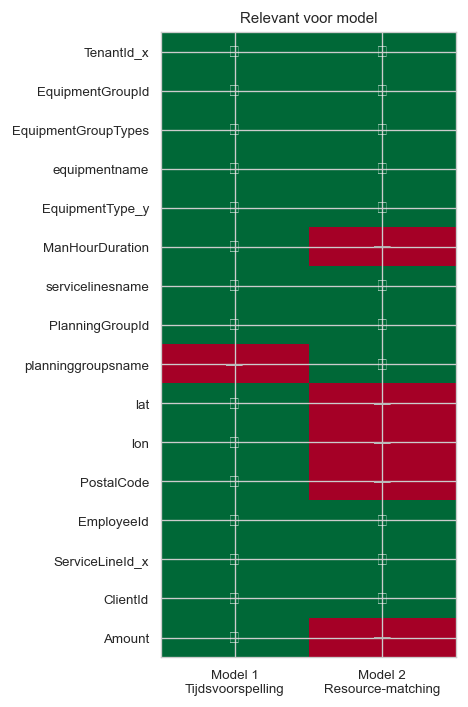

Model 1: 15 | Model 2: 11 features


In [180]:
fig, ax = plt.subplots(figsize=(4, 6))
matrix = df_feat[["model1", "model2"]].values.astype(int)
ax.imshow(matrix, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Model 1\nTijdsvoorspelling", "Model 2\nResource-matching"], fontsize=8)
ax.set_yticks(range(len(df_feat)))
ax.set_yticklabels([r.feature for _, r in df_feat.iterrows()], fontsize=8)
for ri in range(len(df_feat)):
    for ci in range(2):
        v = matrix[ri, ci]
        ax.text(
            ci,
            ri,
            chr(10003) if v else chr(8212),
            ha="center",
            va="center",
            fontsize=10,
            color="white" if v else "#bbb",
            fontweight="bold",
        )
ax.set_title("Relevant voor model", fontsize=9)
plt.tight_layout()
plt.show()
print(f"Model 1: {df_feat['model1'].sum()} | Model 2: {df_feat['model2'].sum()} features")

### 6.5 Medewerker-activiteit dekking (Model 2)

Voor resource-matching moet ik weten welke medewerkers welke activiteiten uitvoeren.
Als een activiteit maar door 1 medewerker gedaan wordt, heeft het model te weinig
variatie om te leren wie er het beste bij past.

In [181]:
tr_m = tabellen["time_registration"].copy()
tr_m = tr_m.merge(
    tabellen["orders"][["orders_id", "TenantId"]],
    left_on="OrderId",
    right_on="orders_id",
    how="left",
)
if "TenantId" in tr_m.columns:
    print("=== Medewerkers per TenantId ===")
    print(tr_m.groupby("TenantId")["EmployeeId"].nunique().to_string())
    print(f"\nTotaal unieke medewerkers: {tr_m['EmployeeId'].nunique()}")

**Medewerker-activiteit dekking visualiseren**

Links: hoeveel medewerkers voeren elke activiteit uit? Activiteiten met maar 1 medewerker
zijn een risico, er is te weinig variatie om te leren. Rechts: hoeveel activiteiten
doet elke medewerker?

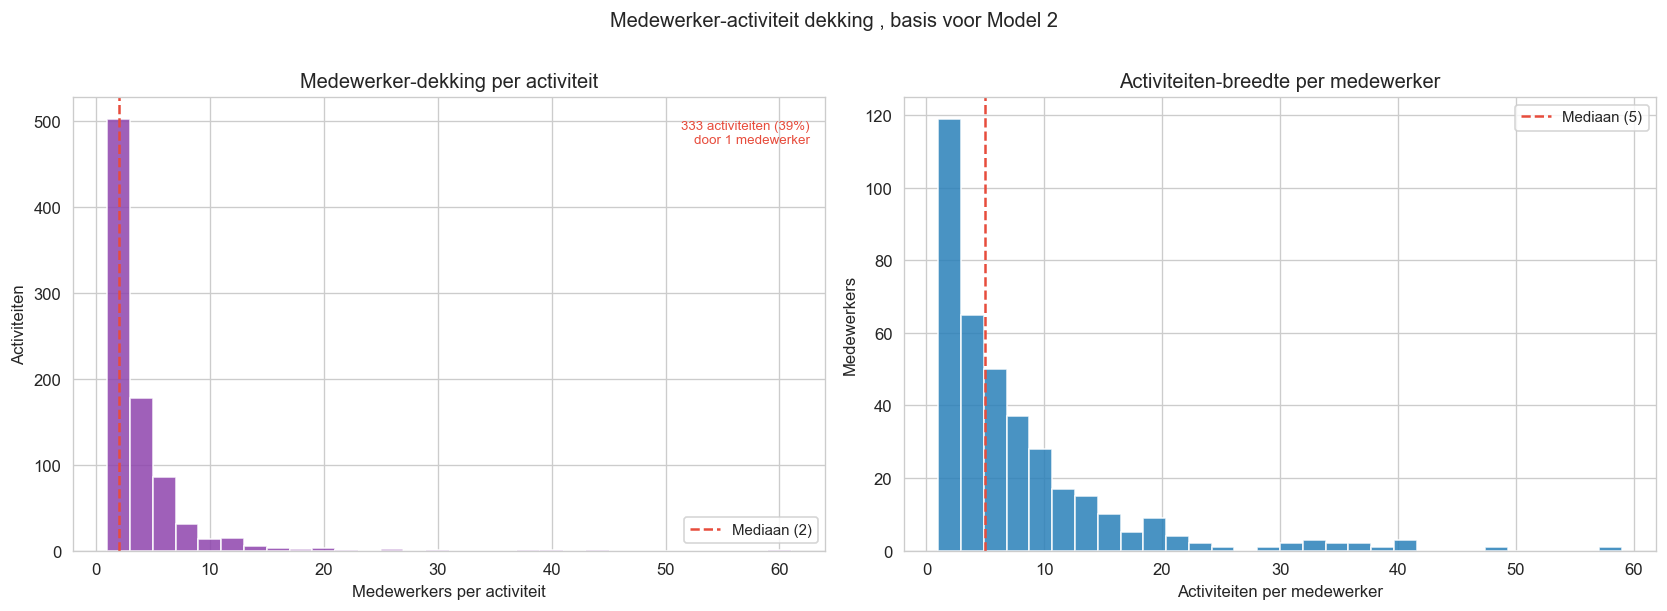

Activiteiten door 1 medewerker: 333 (39.3%)


In [182]:
joined = stap12[["EmployeeId", "servicelinesname"]].dropna()
med_per_act = joined.groupby("servicelinesname")["EmployeeId"].nunique()
act_per_med = joined.groupby("EmployeeId")["servicelinesname"].nunique()
n_single = int((med_per_act == 1).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(med_per_act.values, bins=30, color="#8E44AD", alpha=0.85, edgecolor="white")
axes[0].axvline(
    med_per_act.median(),
    color="#E74C3C",
    lw=1.5,
    ls="--",
    label=f"Mediaan ({med_per_act.median():.0f})",
)
axes[0].text(
    0.98,
    0.95,
    f"{n_single} activiteiten ({n_single / len(med_per_act) * 100:.0f}%)\ndoor 1 medewerker",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=8,
    color="#E74C3C",
)
axes[0].set(
    xlabel="Medewerkers per activiteit",
    ylabel="Activiteiten",
    title="Medewerker-dekking per activiteit",
)
axes[0].legend(fontsize=9)
axes[1].hist(act_per_med.values, bins=30, color="#2980B9", alpha=0.85, edgecolor="white")
axes[1].axvline(
    act_per_med.median(),
    color="#E74C3C",
    lw=1.5,
    ls="--",
    label=f"Mediaan ({act_per_med.median():.0f})",
)
axes[1].set(
    xlabel="Activiteiten per medewerker",
    ylabel="Medewerkers",
    title="Activiteiten-breedte per medewerker",
)
axes[1].legend(fontsize=9)
plt.suptitle("Medewerker-activiteit dekking , basis voor Model 2", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
print(f"Activiteiten door 1 medewerker: {n_single:,} ({n_single / len(med_per_act) * 100:.1f}%)")

## 7. Samenvatting en cleaning-pipeline

### Risicomatrix per kwaliteitsdimensie

| Dimensie | Oordeel | Toelichting |
|----------|---------|-------------|
| Volledigheid | 🟢 Groen | Kernvelden goed gevuld; enkele optionele velden (PostalAddressId) deels leeg maar niet blokkerend |
| Consistentie | 🟢 Groen | Eén database, FK-integriteit intact, geen cross-tenant ID-conflicten |
| Nauwkeurigheid | 🟠 Oranje | 10.240 overlappende tijdregistraties corrumperen target; outliers in hoeveelheid_uur |
| Tijdigheid | 🟢 Groen | Continue datadekking zonder grote gaten |
| Bruikbaarheid | 🟢 Groen | Voldoende features voor regressor en ranker (zie §6) |

**Conclusie:** Dit notebook is de *eerste stap* in de pipeline voor de Rister-database.
De bevindingen vormen de basis voor het DataPrep-notebook (`notebooks/2.DataPrep/rister.ipynb`),
dat de dataset als volgt opschoont:

| Stap | Actie | Reden |
|------|-------|-------|
| 1 | Filter `OrderStatus ∈ {5, 7, 8, 9, 10}` | Alleen afgeronde/gefactureerde orders |
| 2 | Filter `timeregistration_id IS NOT NULL` | Moet tijdregistratie hebben |
| 3 | Pivot units naar kolommen, behoud alleen "Uur" rijen | Target variable selectie |
| 4 | Verwijder `hoeveelheid_uur ≤ 0` en `> P99` | Outlier removal |
| 5 | Filter op `heeft_extra_eenheid = True` | Hoeveelheid-features nodig |
| 6 | Verwijder overlappende tijdregistraties: langste registratie per medewerker/tijdslot behouden | 10.240 overlaps corrumperen target variable (dubbele uren) |

Na deze stappen is de dataset geschikt voor de LightGBM regressor (tijdsvoorspelling)
en ranker (medewerker-geschiktheid).

Voor de vergelijking met de WerkExpert-databases, zie het WerkExpert EDA-notebook (`notebooks/1.EDA/data_quality_report_v5.ipynb`).